In [22]:
from google.colab import files
print("Please upload train.csv file")
uploaded = files.upload()

Please upload train.csv file


Saving train.csv to train (1).csv


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

print("All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")

All libraries imported successfully!
pandas version: 2.2.2


In [24]:
# Load the dataset
df = pd.read_csv('train.csv')

# Basic information
print("="*50)
print("DATASET INFORMATION")
print("="*50)
print(f"Number of rows (houses): {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")
print("="*50)

# Show first 5 rows
print("\nFirst 5 rows of data:")
df.head()

DATASET INFORMATION
Number of rows (houses): 1460
Number of columns (features): 81

First 5 rows of data:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [25]:
# Check data types of each column
print("Data Types Summary:")
print(df.dtypes.value_counts())
print("\nFirst 10 columns and their types:")
print(df.dtypes.head(10))

Data Types Summary:
object     43
int64      35
float64     3
Name: count, dtype: int64

First 10 columns and their types:
Id               int64
MSSubClass       int64
MSZoning        object
LotFrontage    float64
LotArea          int64
Street          object
Alley           object
LotShape        object
LandContour     object
Utilities       object
dtype: object


In [26]:
# Show statistics for numerical columns
print("Statistical Summary for Numerical Columns:")
df.describe()

Statistical Summary for Numerical Columns:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [27]:
# Analyze what we're trying to predict
print("="*50)
print("TARGET VARIABLE ANALYSIS - SalePrice")
print("="*50)
print(f"Minimum price: ${df['SalePrice'].min():,.2f}")
print(f"Maximum price: ${df['SalePrice'].max():,.2f}")
print(f"Average price: ${df['SalePrice'].mean():,.2f}")
print(f"Median price: ${df['SalePrice'].median():,.2f}")
print("="*50)

TARGET VARIABLE ANALYSIS - SalePrice
Minimum price: $34,900.00
Maximum price: $755,000.00
Average price: $180,921.20
Median price: $163,000.00


In [28]:
# Find columns with missing data
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_data = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_percent
})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print(f"Total columns with missing values: {len(missing_data)}")
print("\nColumns with missing values:")
missing_data

Total columns with missing values: 19

Columns with missing values:


,Missing Count,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


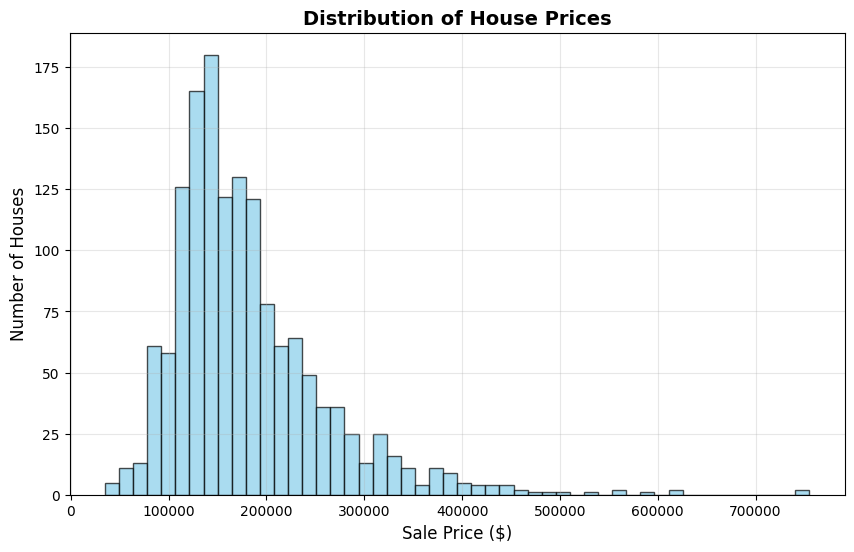

Most houses are priced between $100,000 and $200,000


In [29]:
# Create histogram of house prices
plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Sale Price ($)', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print("Most houses are priced between $100,000 and $200,000")

Top 10 Features Most Correlated with Price:
1. OverallQual: 0.791
2. GrLivArea: 0.709
3. GarageCars: 0.640
4. GarageArea: 0.623
5. TotalBsmtSF: 0.614
6. 1stFlrSF: 0.606
7. FullBath: 0.561
8. TotRmsAbvGrd: 0.534
9. YearBuilt: 0.523
10. YearRemodAdd: 0.507


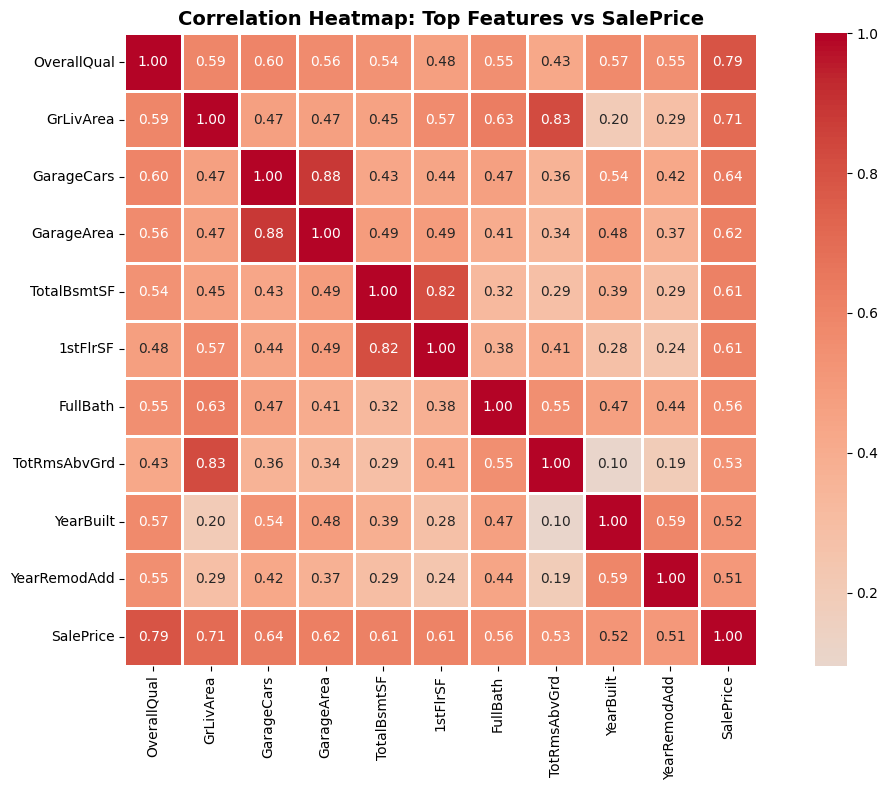

In [30]:
# Find top 10 features most correlated with price
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlations = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

print("Top 10 Features Most Correlated with Price:")
print("="*50)
for i in range(1, 11):
    print(f"{i}. {correlations.index[i]}: {correlations.iloc[i]:.3f}")
print("="*50)

# Create heatmap of top features
top_features = correlations[1:11].index.tolist()
plt.figure(figsize=(12, 8))
sns.heatmap(df[top_features + ['SalePrice']].corr(),
            annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=1)
plt.title('Correlation Heatmap: Top Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

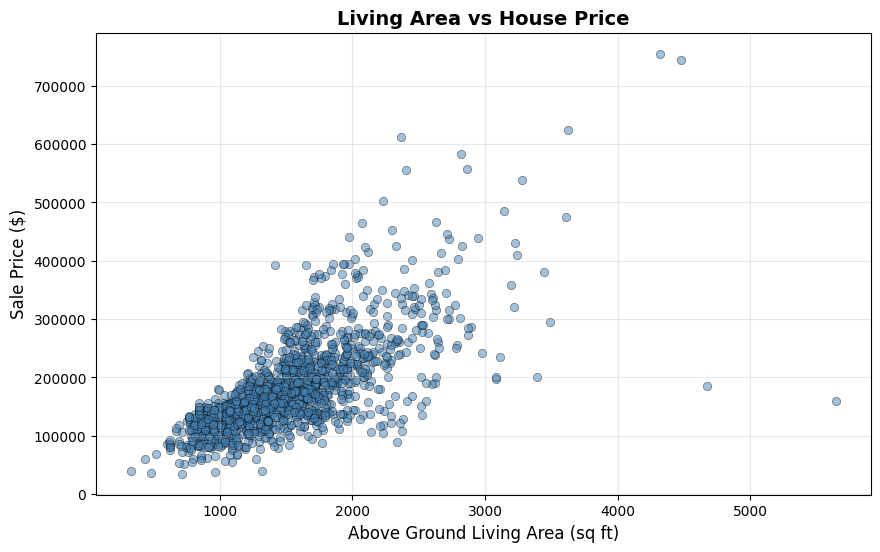

Correlation between Living Area and Price: 0.709
(1.0 = perfect positive relationship, 0 = no relationship)


In [31]:
# Scatter plot of GrLivArea vs SalePrice
plt.figure(figsize=(10, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='steelblue', edgecolors='black', linewidth=0.5)
plt.xlabel('Above Ground Living Area (sq ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.title('Living Area vs House Price', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation
correlation = df['GrLivArea'].corr(df['SalePrice'])
print(f"Correlation between Living Area and Price: {correlation:.3f}")
print("(1.0 = perfect positive relationship, 0 = no relationship)")

In [32]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print("\nFilling missing values...")

# Fill numerical with median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Fill categorical with mode (most frequent value)
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
if df.isnull().sum().sum() == 0:
    print("✓ All missing values have been filled!")

Numerical columns: 38
Categorical columns: 43

Filling missing values...

Missing values remaining: 0
✓ All missing values have been filled!


/tmp/ipykernel_2802/3925520549.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2802/3925520549.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [33]:
# Convert text columns to numbers
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Encoding {len(categorical_cols)} categorical columns...")

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"  ✓ Encoded: {col}")

print("\nAll columns are now numerical!")
print(f"Data types: {df.dtypes.value_counts()}")

Encoding 43 categorical columns...
  ✓ Encoded: MSZoning
  ✓ Encoded: Street
  ✓ Encoded: Alley
  ✓ Encoded: LotShape
  ✓ Encoded: LandContour
  ✓ Encoded: Utilities
  ✓ Encoded: LotConfig
  ✓ Encoded: LandSlope
  ✓ Encoded: Neighborhood
  ✓ Encoded: Condition1
  ✓ Encoded: Condition2
  ✓ Encoded: BldgType
  ✓ Encoded: HouseStyle
  ✓ Encoded: RoofStyle
  ✓ Encoded: RoofMatl
  ✓ Encoded: Exterior1st
  ✓ Encoded: Exterior2nd
  ✓ Encoded: MasVnrType
  ✓ Encoded: ExterQual
  ✓ Encoded: ExterCond
  ✓ Encoded: Foundation
  ✓ Encoded: BsmtQual
  ✓ Encoded: BsmtCond
  ✓ Encoded: BsmtExposure
  ✓ Encoded: BsmtFinType1
  ✓ Encoded: BsmtFinType2
  ✓ Encoded: Heating
  ✓ Encoded: HeatingQC
  ✓ Encoded: CentralAir
  ✓ Encoded: Electrical
  ✓ Encoded: KitchenQual
  ✓ Encoded: Functional
  ✓ Encoded: FireplaceQu
  ✓ Encoded: GarageType
  ✓ Encoded: GarageFinish
  ✓ Encoded: GarageQual
  ✓ Encoded: GarageCond
  ✓ Encoded: PavedDrive
  ✓ Encoded: PoolQC
  ✓ Encoded: Fence
  ✓ Encoded: MiscFeature
  ✓ E

In [34]:
# Check if any text columns remain
text_remaining = df.select_dtypes(include=['object']).columns
if len(text_remaining) == 0:
    print("✓ Success! All data is now numerical.")
else:
    print(f"Warning: {len(text_remaining)} text columns remain:")
    print(text_remaining)

✓ Success! All data is now numerical.


In [35]:
# Split into features (X) and target (y)
X = df.drop(['SalePrice', 'Id'], axis=1)
y = df['SalePrice']

print(f"Features (X): {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Target (y): {y.shape[0]} prices")
print(f"\nFirst 5 features (sample):")
X.head()

Features (X): 1460 rows, 79 columns
Target (y): 1460 prices

First 5 features (sample):


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450,1,0,3,3,0,4,...,0,0,2,2,2,0,2,2008,8,4
1,20,3,80.0,9600,1,0,3,3,0,2,...,0,0,2,2,2,0,5,2007,8,4
2,60,3,68.0,11250,1,0,0,3,0,4,...,0,0,2,2,2,0,9,2008,8,4
3,70,3,60.0,9550,1,0,0,3,0,0,...,0,0,2,2,2,0,2,2006,8,0
4,60,3,84.0,14260,1,0,0,3,0,2,...,0,0,2,2,2,0,12,2008,8,4


In [36]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("="*50)
print("DATA SPLIT SUMMARY")
print("="*50)
print(f"Training set: {X_train.shape[0]} houses ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]} houses ({len(X_test)/len(X)*100:.0f}%)")
print("="*50)

DATA SPLIT SUMMARY
Training set: 1168 houses (80%)
Testing set:  292 houses (20%)


In [37]:
print("Training Linear Regression Model...")
print("-"*30)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("✓ Model trained successfully!")
print(f"  Trained on {X_train.shape[0]} houses")
print(f"  Features used: {X_train.shape[1]}")

# Make predictions
y_pred_lr = lr_model.predict(X_test)
print("✓ Predictions made on", X_test.shape[0], "test houses")

Training Linear Regression Model...
------------------------------
✓ Model trained successfully!
  Trained on 1168 houses
  Features used: 79
✓ Predictions made on 292 test houses


In [38]:
print("Training Random Forest Model...")
print("-"*30)
print("This may take 15-20 seconds...")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("✓ Model trained successfully!")
print(f"  Trained on {X_train.shape[0]} houses")
print(f"  Using 100 decision trees")

# Make predictions
y_pred_rf = rf_model.predict(X_test)
print("✓ Predictions made on", X_test.shape[0], "test houses")

Training Random Forest Model...
------------------------------
This may take 15-20 seconds...
✓ Model trained successfully!
  Trained on 1168 houses
  Using 100 decision trees
✓ Predictions made on 292 test houses


In [39]:
# Calculate metrics for Linear Regression
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculate metrics for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Print results
print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(f"{'Model':<20} {'R² Score':<15} {'RMSE (Error)':<15}")
print("-"*60)
print(f"{'Linear Regression':<20} {r2_lr:<15.4f} ${rmse_lr:<14,.2f}")
print(f"{'Random Forest':<20} {r2_rf:<15.4f} ${rmse_rf:<14,.2f}")
print("="*60)

# Explain what the numbers mean
print("\n📊 WHAT THESE NUMBERS MEAN:")
print(f"• R² Score (0 to 1): Higher is better")
print(f"  - Linear Regression: {r2_lr*100:.1f}% accurate")
print(f"  - Random Forest: {r2_rf*100:.1f}% accurate")
print(f"\n• RMSE: Average prediction error in dollars")
print(f"  - Linear Regression: Off by ${rmse_lr:,.0f} on average")
print(f"  - Random Forest: Off by ${rmse_rf:,.0f} on average")

# Winner
if r2_rf > r2_lr:
    print(f"\n🏆 WINNER: Random Forest is {((r2_rf - r2_lr)*100):.1f}% more accurate!")
else:
    print(f"\n🏆 WINNER: Linear Regression is {((r2_lr - r2_rf)*100):.1f}% more accurate!")

MODEL PERFORMANCE COMPARISON
Model                R² Score        RMSE (Error)   
------------------------------------------------------------
Linear Regression    0.8374          $35,312.14     
Random Forest        0.8944          $28,455.23     

📊 WHAT THESE NUMBERS MEAN:
• R² Score (0 to 1): Higher is better
  - Linear Regression: 83.7% accurate
  - Random Forest: 89.4% accurate

• RMSE: Average prediction error in dollars
  - Linear Regression: Off by $35,312 on average
  - Random Forest: Off by $28,455 on average

🏆 WINNER: Random Forest is 5.7% more accurate!


TOP 10 MOST IMPORTANT FEATURES FOR PRICE PREDICTION
1. OverallQual               -> Importance: 0.5566
2. GrLivArea                 -> Importance: 0.1215
3. TotalBsmtSF               -> Importance: 0.0348
4. 2ndFlrSF                  -> Importance: 0.0347
5. BsmtFinSF1                -> Importance: 0.0291
6. 1stFlrSF                  -> Importance: 0.0269
7. LotArea                   -> Importance: 0.0171
8. GarageArea                -> Importance: 0.0165
9. YearBuilt                 -> Importance: 0.0131
10. GarageCars                -> Importance: 0.0118


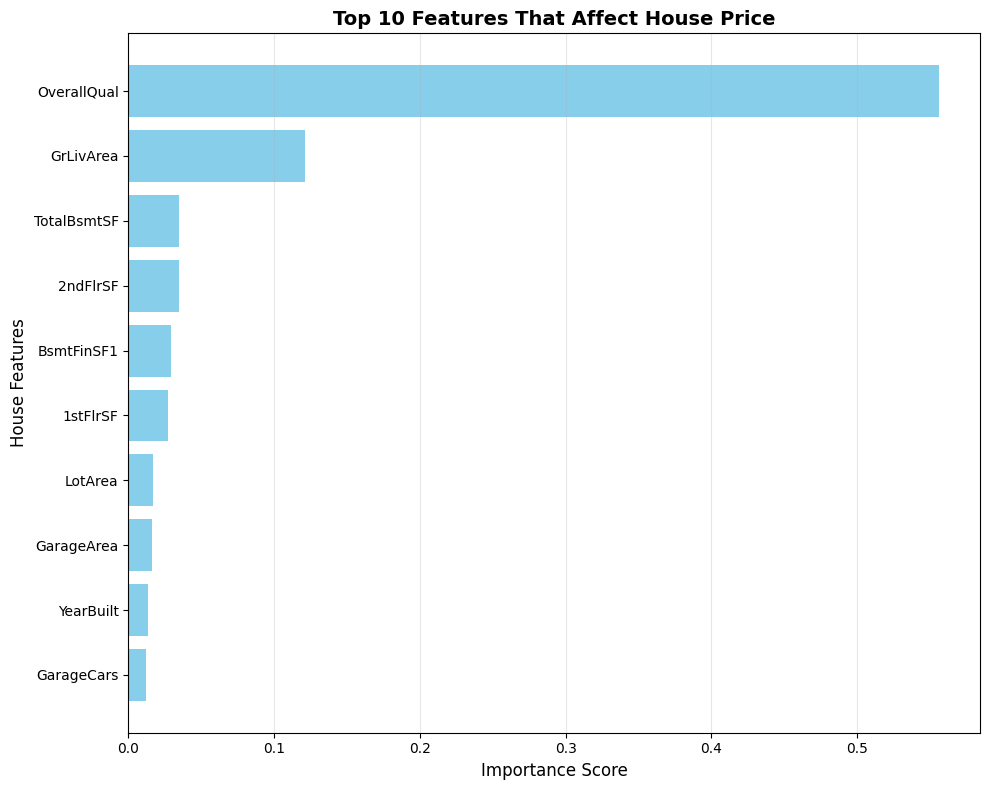


💡 INSIGHT: These features most strongly influence house prices!


In [40]:
# Get feature importances from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Show top 10
print("="*60)
print("TOP 10 MOST IMPORTANT FEATURES FOR PRICE PREDICTION")
print("="*60)
for i in range(10):
    print(f"{i+1}. {feature_importance.iloc[i]['Feature']:25s} -> Importance: {feature_importance.iloc[i]['Importance']:.4f}")
print("="*60)

# Create bar chart
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'], color='skyblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('House Features', fontsize=12)
plt.title('Top 10 Features That Affect House Price', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: These features most strongly influence house prices!")

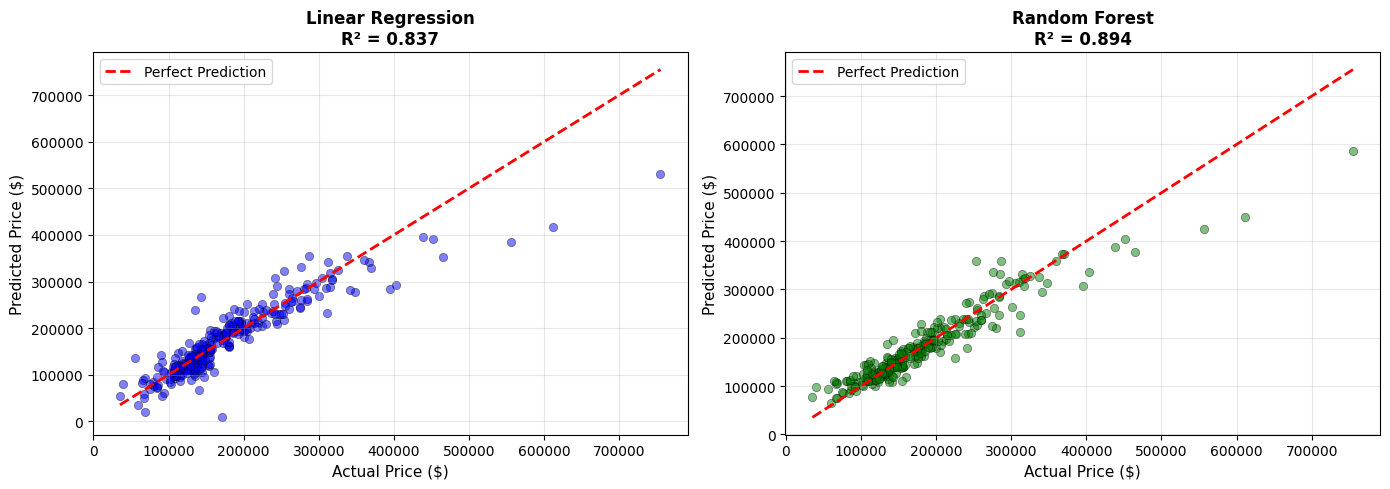

The closer the dots are to the red line, the better the predictions!


In [41]:
# Compare actual vs predicted prices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='blue', edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0].set_title(f'Linear Regression\nR² = {r2_lr:.3f}', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, color='green', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)', fontsize=11)
axes[1].set_ylabel('Predicted Price ($)', fontsize=11)
axes[1].set_title(f'Random Forest\nR² = {r2_rf:.3f}', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The closer the dots are to the red line, the better the predictions!")

In [42]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)
print("\n✅ WHAT WE ACCOMPLISHED:")
print("1. Loaded and explored 1,460 houses with 81 features each")
print("2. Handled missing values (filled with median/mode)")
print("3. Converted text data to numbers")
print("4. Trained 2 machine learning models")
print("5. Evaluated their performance")

print("\n📊 RESULTS:")
print(f"• Linear Regression predicts prices with {r2_lr*100:.1f}% accuracy")
print(f"• Random Forest predicts prices with {r2_rf*100:.1f}% accuracy")

print("\n🔑 KEY INSIGHTS:")
top_feature = feature_importance.iloc[0]['Feature']
print(f"• The most important feature is: {top_feature}")
print("• Living area and overall quality strongly influence price")

print("\n🎯 REAL-WORLD APPLICATION:")
print("Real estate companies use similar models to estimate house values")
print("Banks use them for mortgage approvals")

print("\n" + "="*60)
print("🎉 CONGRATULATIONS! You've built your first ML model!")
print("="*60)

PROJECT SUMMARY

✅ WHAT WE ACCOMPLISHED:
1. Loaded and explored 1,460 houses with 81 features each
2. Handled missing values (filled with median/mode)
3. Converted text data to numbers
4. Trained 2 machine learning models
5. Evaluated their performance

📊 RESULTS:
• Linear Regression predicts prices with 83.7% accuracy
• Random Forest predicts prices with 89.4% accuracy

🔑 KEY INSIGHTS:
• The most important feature is: OverallQual
• Living area and overall quality strongly influence price

🎯 REAL-WORLD APPLICATION:
Real estate companies use similar models to estimate house values
Banks use them for mortgage approvals

🎉 CONGRATULATIONS! You've built your first ML model!
